# Functional connectivity strength correlates of AFD

### Libraries

In [1]:
import os
import numpy as np
import nibabel as nb
import pandas as pd
import glob
import matplotlib.pyplot as plt
from nilearn import plotting
from brainspace.mesh.mesh_io import read_surface
from brainspace.plotting import plot_hemispheres
from brainspace.gradient import GradientMaps
from brainspace.mesh.array_operations import smooth_array
from brainspace.datasets import load_mask
from brainspace.utils.parcellation import map_to_labels
from brainspace.datasets import load_parcellation
from brainspace.null_models import SpinPermutations
from brainstat.datasets import fetch_mask
from brainstat.stats.terms import FixedEffect
from brainstat.stats.SLM import SLM
import scipy.stats as stats
from scipy import stats
import scipy as sp
from scipy.stats import spearmanr
from scipy.stats import pearsonr
from scipy.stats import rankdata
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import networkx as nx
import copy
import cmocean
import statsmodels.api as sm
import pandas as pd
from sklearn.linear_model import LinearRegression
from igraph import Graph
from neuromaps.datasets import fetch_fslr
from surfplot import Plot
from enigmatoolbox.utils.parcellation import surface_to_parcel
from enigmatoolbox.utils.parcellation import parcel_to_surface

### Load surfaces and masks

In [2]:
# Set dataset PNI as working directory
os.chdir('/data_/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0')

# Path to MICAPIPE surf = mask_5k !
micapipe=os.popen("echo $MICAPIPE").read()[:-1]

# Load fsLR 32k
f32k_lh = read_surface(micapipe + '/surfaces/fsLR-32k.L.surf.gii', itype='gii')
f32k_rh = read_surface(micapipe + '/surfaces/fsLR-32k.R.surf.gii', itype='gii')

# Load fsLR 32k inflated
f32k_inf_lh = read_surface(micapipe + '/surfaces/fsLR-32k.L.inflated.surf.gii', itype='gii')
f32k_inf_rh = read_surface(micapipe + '/surfaces/fsLR-32k.R.inflated.surf.gii', itype='gii')
mask_32k = load_mask(join=True)

# Boolean mask
mask_surf = mask_32k != 0

### Functions

## F1: Intensity Smoothing

In [3]:
# Function: Smooth intensity profiles on a given surface
def smooth_surf(surf_l, surf_r, points, Mask, Kernel='uniform', Niter=3, Relax=0.35):
    '''
    Smooths intensity data on a given surface mesh using iterative smoothing.
    
    Parameters:
    -----------
    surf_l : np.array
        Left hemisphere surface connectivity.
    surf_r : np.array
        Right hemisphere surface connectivity.
    points : np.array
        Intensity profile data mapped to the surface.
    Mask : np.array
        Binary mask indicating valid regions for smoothing.
    Kernel : str, optional
        Smoothing kernel type, options: {'uniform', 'gaussian', 'inverse_distance'}.
    Niter : int, optional
        Number of smoothing iterations (default: 3).
    Relax : float, optional
        Relaxation factor controlling smoothing intensity (default: 0.35).
    
    Returns:
    --------
    sdata : np.array
        Smoothed intensity data.
    '''
    Ndim = Mask.shape[0] 
    n2dim = int(Ndim/2)
    Mask_l = Mask[:n2dim]
    Mask_r = Mask[n2dim:]
    
    sdata = np.concatenate((
        smooth_array(surf_l, points[:n2dim], kernel=Kernel, n_iter=Niter, relax=Relax, mask=Mask_l), 
        smooth_array(surf_r, points[n2dim:], kernel=Kernel, n_iter=Niter, relax=Relax, mask=Mask_r)
    ), axis=0)
    
    return sdata

# Function: Apply smoothing to intensity profiles across all depths
def smooth_intensities(int_profile):
    '''
    Applies surface smoothing to each depth of the intensity profile.
    
    Parameters:
    -----------
    int_profile : np.array
        Input intensity profiles, where rows represent different depths.
    
    Returns:
    --------
    smoothed_i : np.array
        Smoothed intensity profiles.
    '''
    smoothed_i = np.copy(int_profile)
    
    for i in range(int_profile.shape[0]):
        smoothed_i[i, :] = smooth_surf(
            f32k_inf_lh, f32k_inf_rh, int_profile[i, :], mask_surf, Niter=5, Relax=0.5, Kernel='uniform'
        )
    
    return smoothed_i

In [4]:
def fill_missing_Turkey(cdata):
    # Calculate the first and third quartiles
    Q1 = np.nanpercentile(cdata, 25)
    Q3 = np.nanpercentile(cdata, 75)

    # Calculate the interquartile range (IQR)
    IQR = Q3 - Q1

    # Define the outlier thresholds based on Tukey's method
    lower_threshold = Q1 - 1.5 * IQR
    upper_threshold = Q3 + 1.5 * IQR

    # Identify outliers based on Tukey's method
    outliers = (cdata < lower_threshold) | (cdata > upper_threshold)

    # Set outliers to NaN
    cdata[outliers] = np.nan

    # Interpolate NaNs
    good = np.where(~np.isnan(cdata))
    bad = np.where(np.isnan(cdata))
    fill = sp.interpolate.griddata(good, cdata[good], bad)
    cdata[bad] = fill

    # Extrapolate any remaining missing values
    good = np.where(~np.isnan(cdata))
    bad = np.where(np.isnan(cdata))
    fill = sp.interpolate.griddata(good, cdata[good], bad, method='nearest')
    cdata[bad] = fill
    
    return cdata

## F2: Compute Functional Connectivity 

In [5]:
from scipy.stats import zscore

def compute_fc_matrix(time_series: np.ndarray) -> np.ndarray:
    """
    Compute the functional connectivity (FC) matrix using Pearson correlation.

    Parameters:
    - time_series (np.ndarray): 2D array of shape (n_timepoints, n_vertices)

    Returns:
    - fc_matrix (np.ndarray): 2D array of shape (n_vertices, n_vertices)
    """
    # Transpose to (n_vertices, n_timepoints)
    time_series = time_series.T
    
    # Z-score normalization across timepoints (axis=1)
    ts_z = zscore(time_series, axis=1, ddof=1)
    
    # Compute Pearson correlation matrix
    fc_matrix = np.corrcoef(ts_z)
    
    return fc_matrix

## F3: Spin permutations: Brain functional connectivity ~ SWM long-range fibers by subject

In [6]:
# Shape of the fsLR-32k matrices
N5k = 64984

# Load spheres fsLR32k
sphere_lh = read_surface(micapipe+'/surfaces/fsLR-32k.L.sphere.surf.gii', itype='gii')
sphere_rh = read_surface(micapipe+'/surfaces/fsLR-32k.R.sphere.surf.gii', itype='gii')

# Let's create some rotations
n_rand = 1000

spinp = SpinPermutations(n_rep=n_rand, random_state=0)
spinp.fit(sphere_lh, points_rh=sphere_rh)

SpinPermutations(n_rep=1000, random_state=0)

In [52]:
def plot_func_spin_permutations(sub7T_id, sub3T_di):
    # Load functional connectivity data (left & right hemispheres)
    ffile_path = glob.glob(f"/data/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0/sub-PNC0{sub7T_id}/ses-a1/func/desc-me_task-rest_bold/surf/*_atlas-schaefer-400_desc-FC.shape.gii")[0]
    fdata = nb.load(ffile_path).darrays[0].data

    #Fisher transform
    FCz = np.arctanh(fdata)
    # replace inf with 0
    FCz[~np.isfinite(FCz)] = 0
    fc_sym = np.triu(FCz,1)+FCz.T
    # Consider the absolute value
    fc_abs = np.abs(fc_sym)
    # Compute weighted degree centrality measures from the connectivity data
    fc_ctx = np.sum(fc_abs, axis=0)
    fc_ctx_dc = parcel_to_surface(fc_ctx, 'schaefer_400_conte69')
   
    fdata_L = fc_ctx_dc[0:int(N5k/2)]
    fdata_R = fc_ctx_dc[int(N5k/2):N5k]

    ###################################################################################################
    # Load apparent fiber density maps - Long-range fibers
    base_dir = '/host/verges/tank/data/youngeun/myproject/FBA/subjects'
    subj_path = os.path.join(base_dir, sub3T_di, 'csd_msmt')
    lh_LFpath = os.path.join(subj_path, 'L_fsLR32k_afd-par.txt')
    rh_LFpath = os.path.join(subj_path, 'R_fsLR32k_afd-par.txt')
    
    lh_LFpar = np.loadtxt(lh_LFpath)
    rh_LFpar = np.loadtxt(rh_LFpath)

    # column 0 (0mm), 2 (1mm), 4 (2mm)
    LFpar_0mm = np.concatenate((lh_LFpar[:, 0], rh_LFpar[:, 0]), axis=0)
    LFpar_1mm = np.concatenate((lh_LFpar[:, 2], rh_LFpar[:, 2]), axis=0)
    LFpar_2mm = np.concatenate((lh_LFpar[:, 4], rh_LFpar[:, 4]), axis=0)

    # Convert -1 to NaN for missing values
    LFpar_0mm[LFpar_0mm == -1] = np.nan
    LFpar_1mm[LFpar_1mm == -1] = np.nan
    LFpar_2mm[LFpar_2mm == -1] = np.nan
    
    LFpar_SWM = np.vstack([LFpar_0mm, LFpar_1mm, LFpar_2mm])  # shape: (3, vertices)

    # Fill missing data using Turkey's method
    LF_filled_matrix = np.empty_like(LFpar_SWM)
    for i, row in enumerate(LFpar_SWM):
        LF_filled_matrix[i] = fill_missing_Turkey(row)

    LF_par_smooth = smooth_intensities(LF_filled_matrix)
    LF_2mm = LF_par_smooth[2, :]
    LF_2mm_parc = surface_to_parcel(LF_2mm, 'schaefer_400_conte69')
    LF_2mm_dc = parcel_to_surface(LF_2mm_parc, 'schaefer_400_conte69')
    
    ###################################################################################################
    # Load apparent fiber density maps - U-fibers
    lh_UFpath = os.path.join(subj_path, 'L_fsLR32k_afd-perp-av.txt')
    rh_UFpath = os.path.join(subj_path, 'R_fsLR32k_afd-perp-av.txt')
    
    lh_UFpar = np.loadtxt(lh_UFpath)
    rh_UFpar = np.loadtxt(rh_UFpath)

    # column 0 (0mm), 2 (1mm), 4 (2mm)
    UFpar_0mm = np.concatenate((lh_UFpar[:, 0], rh_UFpar[:, 0]), axis=0)
    UFpar_1mm = np.concatenate((lh_UFpar[:, 2], rh_UFpar[:, 2]), axis=0)
    UFpar_2mm = np.concatenate((lh_UFpar[:, 4], rh_UFpar[:, 4]), axis=0)

    # Convert -1 to NaN for missing values
    UFpar_0mm[UFpar_0mm == -1] = np.nan
    UFpar_1mm[UFpar_1mm == -1] = np.nan
    UFpar_2mm[UFpar_2mm == -1] = np.nan
    
    UFpar_SWM = np.vstack([UFpar_0mm, UFpar_1mm, UFpar_2mm])  # shape: (3, vertices)

    # Fill missing data using Turkey's method
    UF_filled_matrix = np.empty_like(UFpar_SWM)
    for i, row in enumerate(UFpar_SWM):
        UF_filled_matrix[i] = fill_missing_Turkey(row)

    UF_par_smooth = smooth_intensities(UF_filled_matrix)
    UF_2mm = UF_par_smooth[2, :]
    UF_2mm_parc = surface_to_parcel(UF_2mm, 'schaefer_400_conte69')
    UF_2mm_dc = parcel_to_surface(UF_2mm_parc, 'schaefer_400_conte69')

    ###################################################################################################
    # Spin permutation on full data (Get the rotated data)
    func_rotated = np.hstack(spinp.randomize(fdata_L, fdata_R))
    
    AFDs = {'long-range fibers': LF_2mm_dc, 'u-fibers': UF_2mm_dc}
    
    # Plotting
    fig, axs = plt.subplots(1, 2, figsize=(8, 4))
    
    for k, (fn, AFD) in enumerate(AFDs.items()):

        mask = ~np.isnan(fc_ctx_dc) & ~np.isnan(AFD)
        non_zero_mask = ~((fc_ctx_dc[mask] == 0) & (AFD[mask] == 0))
        valid_fc = fc_ctx_dc[mask][non_zero_mask]
        valid_afd = AFD[mask][non_zero_mask]
        
        # Observed correlation
        r_obs, p_obs = spearmanr(valid_fc, valid_afd)
        
        # Permutation-based correlations
        r_spin = np.array([spearmanr(perm[mask][non_zero_mask], valid_afd)[0] for perm in func_rotated])
        p_spin = np.mean(np.abs(r_spin) >= np.abs(r_obs))
        
        # Plot null distribution
        axs[k].hist(r_spin, bins=25, density=True, alpha=0.5, color=(.6, .6, .6))
        axs[k].axvline(r_obs, lw=2, ls='--', color='k')
        axs[k].set_xlabel(f'Correlation with {fn}')
        if k == 0:
            axs[k].set_ylabel('Density')
        #textstr = f'Obs: r = {r_obs:.3f}, p = {p_obs:.3f}\nSpin: r = {np.mean(r_spin):.3f}, p = {p_spin:.3f}'
        textstr = f"r = {r_obs:.3f}, $P_{{spin}}$ = {p_spin:.3f}"
        axs[k].text(0.95, 0.95, textstr, transform=axs[k].transAxes, fontsize=12,
                    verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round,pad=0.3', edgecolor='gray', facecolor='white'))
    
    fig.tight_layout()
    plt.show()

/tmp/ipykernel_3184527/391972381.py:7: RuntimeWarning: divide by zero encountered in arctanh
  FCz = np.arctanh(fdata)


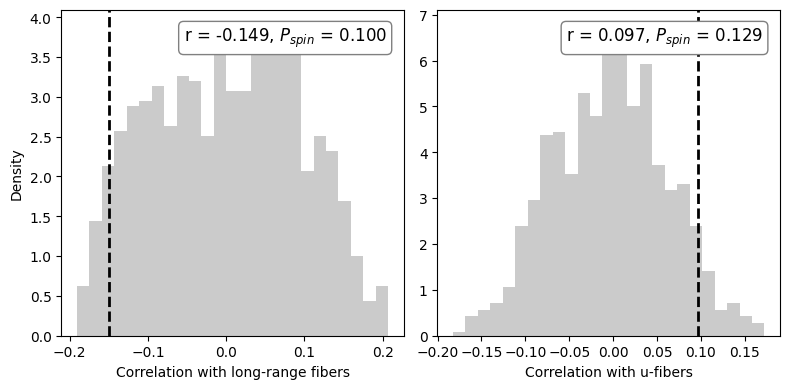

In [35]:
plot_func_spin_permutations(sub7T_id="03", sub3T_di="PNC003_HC082")

/tmp/ipykernel_3184527/391972381.py:7: RuntimeWarning: divide by zero encountered in arctanh
  FCz = np.arctanh(fdata)


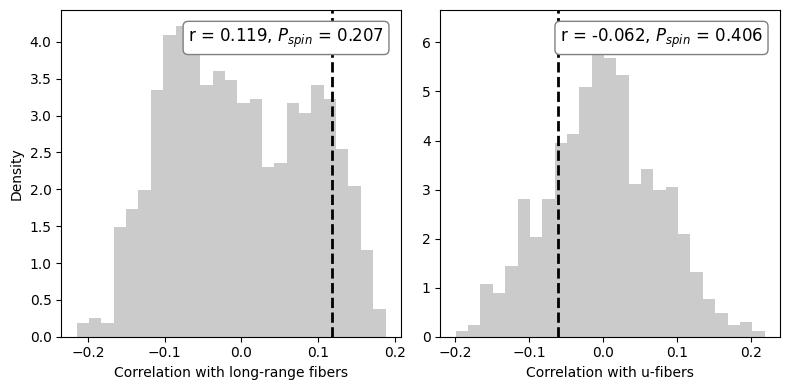

In [36]:
plot_func_spin_permutations(sub7T_id="06", sub3T_di="PNC006_HC081")

/tmp/ipykernel_3184527/391972381.py:7: RuntimeWarning: divide by zero encountered in arctanh
  FCz = np.arctanh(fdata)


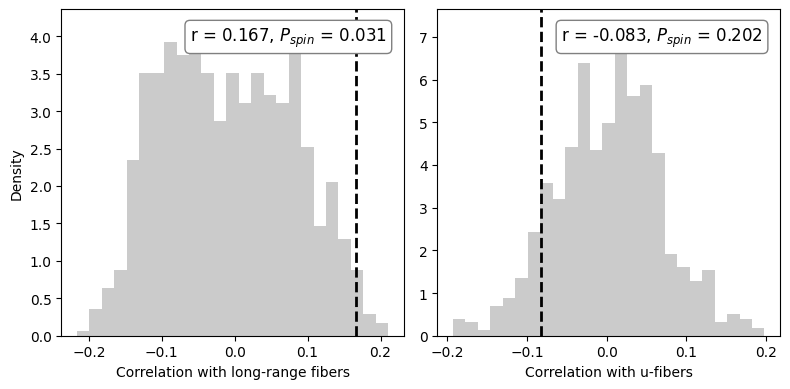

In [37]:
plot_func_spin_permutations(sub7T_id="11", sub3T_di="PNC011_HC083")

In [38]:
plot_func_spin_permutations(sub7T_id="18", sub3T_di="PNC018_HC076")

IndexError: list index out of range

/tmp/ipykernel_3184527/391972381.py:7: RuntimeWarning: divide by zero encountered in arctanh
  FCz = np.arctanh(fdata)


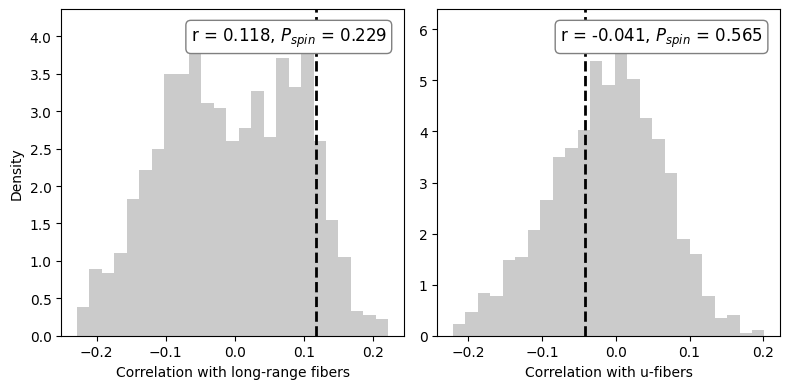

In [39]:
plot_func_spin_permutations(sub7T_id="19", sub3T_di="PNC019_HC062")

/tmp/ipykernel_3184527/391972381.py:7: RuntimeWarning: divide by zero encountered in arctanh
  FCz = np.arctanh(fdata)


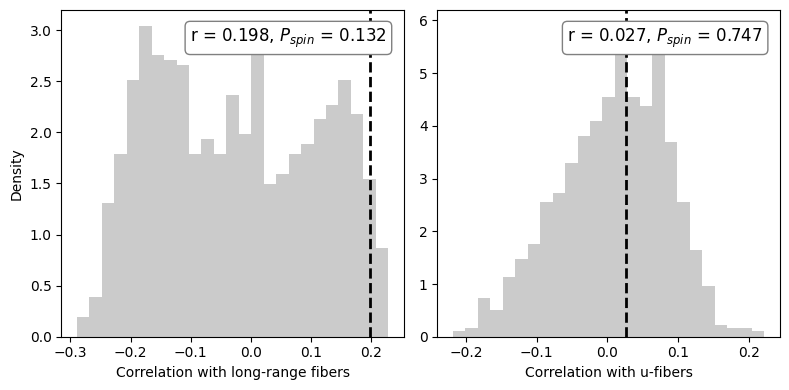

In [40]:
plot_func_spin_permutations(sub7T_id="22", sub3T_di="PNC022_HC132")

/tmp/ipykernel_3184527/1183954333.py:7: RuntimeWarning: divide by zero encountered in arctanh
  FCz = np.arctanh(fdata)


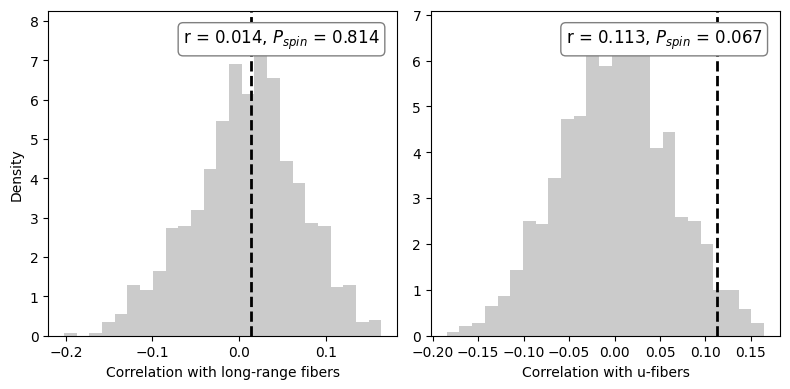

In [51]:
plot_func_spin_permutations(sub7T_id="24", sub3T_di="PNC024_HC088")

/tmp/ipykernel_3184527/2257790706.py:7: RuntimeWarning: divide by zero encountered in arctanh
  FCz = np.arctanh(fdata)


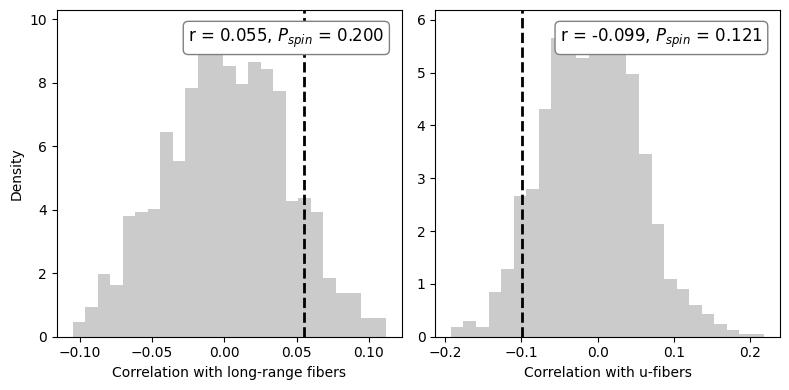

In [53]:
plot_func_spin_permutations(sub7T_id="25", sub3T_di="PNC025_HC128")

/tmp/ipykernel_3184527/2257790706.py:7: RuntimeWarning: divide by zero encountered in arctanh
  FCz = np.arctanh(fdata)


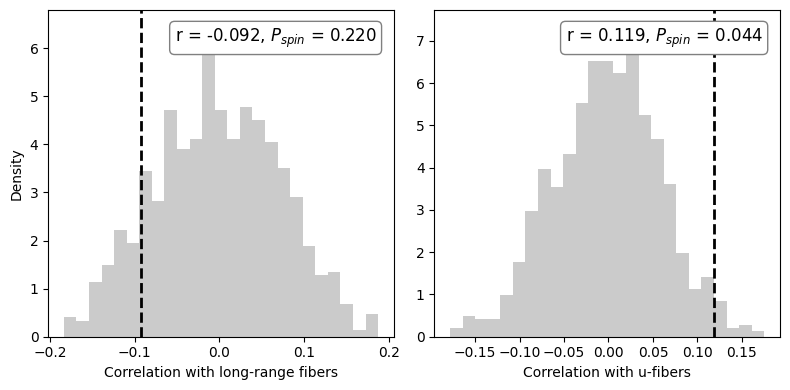

In [54]:
plot_func_spin_permutations(sub7T_id="26", sub3T_di="PNC026_HC130")

/tmp/ipykernel_3184527/2257790706.py:7: RuntimeWarning: divide by zero encountered in arctanh
  FCz = np.arctanh(fdata)


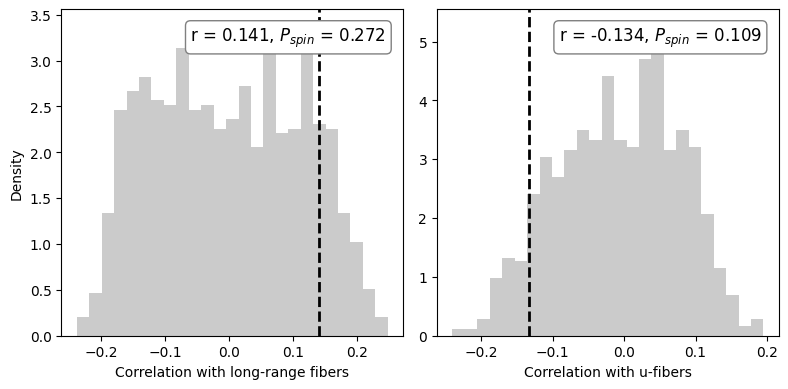

In [55]:
plot_func_spin_permutations(sub7T_id="37", sub3T_di="PNC037_HC116")

/tmp/ipykernel_3184527/2257790706.py:7: RuntimeWarning: divide by zero encountered in arctanh
  FCz = np.arctanh(fdata)


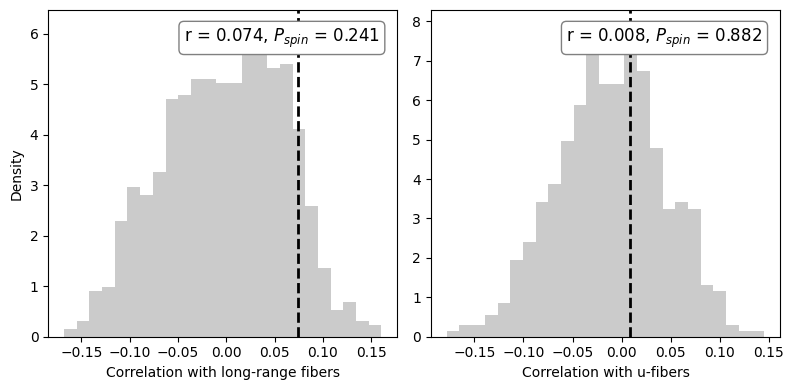

In [56]:
plot_func_spin_permutations(sub7T_id="38", sub3T_di="PNC038_HC140")